# 01: Dataset Audit

## Objective

Before model development, verify the provenance, structure, outcome coding, and predictor definitions of the Wisconsin Diagnostic Breast Cancer (WDBC) dataset.

This stage is intentionally performed before model fitting or outcome-driven exploration.

The objectives are to establish:
1. the exact analysis dataset;
2. the observational unit;
3. the meaning and structure of the predictors;
4. the positive-outcome convention;
5. the absence or presence of missing values and exact duplicate predictor rows;
6. reproducible structural checks that future runs of the analysis must satisfy.

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import sklearn

data = load_breast_cancer(as_frame=True)
X = data.data.copy()
y_original = data.target.copy()
y = (y_original == 0).astype(int)
y.name = "malignant"

## Dataset representation

The analysis uses the WDBC dataset distributed through `sklearn.datasets.load_breast_cancer`.

The dataset contains:
- 569 observations;
- 30 quantitative predictors derived from nuclear morphology;
- 212 malignant observations;
- 357 benign observations.

The scikit-learn representation encodes:
- `0 = malignant`
- `1 = benign`

For this project, the outcome is explicitly recoded as:
- `1 = malignant`
- `0 = benign`

This convention ensures that predicted probabilities consistently refer to the probability of malignancy.

All subsequent model evaluation will use this explicitly recoded outcome rather than relying on the original class ordering.

## Structural audit

The initial structural audit confirmed:
- predictor matrix shape: `569 × 30`;
- all predictors are numeric (`float64`);
- no missing predictor values;
- no missing outcome values;
- no exact duplicate rows across the 30 predictors;
- all expected malignant and benign observations are present;
- no predictor is constant.

The absence of exact duplicate predictor rows does not establish statistical independence of the observations. It only confirms that no two rows contain identical values across all 30 predictors.

In [2]:
feature_audit = pd.DataFrame({
    "feature": X.columns,
    "dtype": X.dtypes.astype(str).values,
    "missing": X.isna().sum().values,
    "n_unique": X.nunique().values,
    "min": X.min().values,
    "max": X.max().values,
})
feature_audit

,feature,dtype,missing,n_unique,min,max
0,mean radius,float64,0,456,6.981000,28.11000
1,mean texture,float64,0,479,9.710000,39.28000
2,mean perimeter,float64,0,522,43.790000,188.50000
3,mean area,float64,0,539,143.500000,2501.00000
4,mean smoothness,float64,0,474,0.052630,0.16340
5,mean compactness,float64,0,537,0.019380,0.34540
6,mean concavity,float64,0,537,0.000000,0.42680
7,mean concave points,float64,0,542,0.000000,0.20120
8,mean symmetry,float64,0,432,0.106000,0.30400
9,mean fractal dimension,float64,0,499,0.049960,0.09744


## Predictor provenance and structure

The 30 predictors are constructed from ten underlying nuclear-morphology characteristics (radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension).

Each characteristic is represented using three summaries: `mean`, `standard error`, and `worst`.

$$
10 \text{ morphological characteristics} \times 3 \text{ summaries} = 30 \text{ predictors}.
$$

### Structural validation result

All 30 predictor names matched the expected WDBC feature structure.

## Implications for the analysis

The WDBC predictors contain known structural relationships. Predictor dependence is expected from the feature-construction process itself.

All 30 predictors will remain part of the prespecified analysis dataset.

##
Decisions frozen after Stage 1A–1B

- use the scikit-learn representation of WDBC;
- retain all 569 observations;
- retain all 30 quantitative predictors;
- explicitly encode malignant as `1`;
- perform no imputation or feature selection during dataset preparation.

## Analyses deliberately not performed at this stage

No model fitting, train/test splitting, feature selection, PCA, or hyperparameter optimization was performed during the dataset audit.

## Observation identifiers

The scikit-learn representation used in this project does not expose the
original UCI case identifier as an analysis variable.

Stable internal identifiers (`WDBC_000` to `WDBC_568`) were therefore created
solely for tracking observations across resampling repetitions and generated
result tables.

These identifiers are analytical row identifiers and must not be interpreted
as original patient identifiers.

In [3]:
# 1. Crear IDs estables internos
observation_id = pd.Series(
    [f"WDBC_{i:03d}" for i in range(len(X))],
    name="observation_id"
)

print(observation_id.head())

0    WDBC_000
1    WDBC_001
2    WDBC_002
3    WDBC_003
4    WDBC_004
Name: observation_id, dtype: str


In [4]:
# 2. Construir la tabla máster de análisis
analysis_df = X.copy()

analysis_df.insert(0, "observation_id", observation_id.values)
analysis_df["malignant"] = y.values

print("Analysis table shape:", analysis_df.shape)
print("Unique observation IDs:", analysis_df["observation_id"].nunique())
print("Number malignant:", analysis_df["malignant"].sum())

Analysis table shape: (569, 32)
Unique observation IDs: 569
Number malignant: 212


In [5]:
# 3. Nombres de columnas congelados
FEATURE_COLUMNS = tuple(X.columns)
TARGET_COLUMN = "malignant"
ID_COLUMN = "observation_id"

print("Number of feature columns:", len(FEATURE_COLUMNS))
print("Target:", TARGET_COLUMN)
print("ID:", ID_COLUMN)

# Separación segura
X_analysis = analysis_df.loc[:, FEATURE_COLUMNS].copy()
y_analysis = analysis_df[TARGET_COLUMN].copy()
ids_analysis = analysis_df[ID_COLUMN].copy()

Number of feature columns: 30
Target: malignant
ID: observation_id


## Analysis data contract

All subsequent analyses must operate on the same frozen representation:

- observational unit: one WDBC breast-mass case;
- number of observations: 569;
- predictors: the 30 predefined quantitative WDBC morphology variables;
- predictor order: preserved exactly as distributed by scikit-learn;
- outcome: binary diagnosis recoded as `malignant = 1`, `benign = 0`;
- observation identifier: project-specific internal ID, excluded from modeling;
- missing-value handling: none required;
- feature selection during data preparation: none.

The model input is therefore:

$$X \in \mathbb{R}^{569 \times 30}$$

and:

$$y \in \{0,1\}^{569},$$

where `1` denotes malignancy.

Observation identifiers and the outcome column are never included in the predictor matrix.

In [6]:
# 5. Comprobaciones automáticas de integridad
assert analysis_df.shape == (569, 32)

assert analysis_df[ID_COLUMN].is_unique
assert analysis_df[ID_COLUMN].notna().all()

assert len(FEATURE_COLUMNS) == 30
assert len(set(FEATURE_COLUMNS)) == 30

assert list(X_analysis.columns) == list(FEATURE_COLUMNS)
assert X_analysis.shape == (569, 30)

assert X_analysis.isna().sum().sum() == 0

assert set(y_analysis.unique()) == {0, 1}
assert y_analysis.sum() == 212
assert (y_analysis == 0).sum() == 357

assert ID_COLUMN not in FEATURE_COLUMNS
assert TARGET_COLUMN not in FEATURE_COLUMNS

assert X_analysis.index.equals(y_analysis.index)
assert X_analysis.index.equals(ids_analysis.index)

print("Analysis data contract checks passed.")

Analysis data contract checks passed.


In [7]:
import hashlib
import numpy as np

def compute_dataset_fingerprint(X, y, feature_names):
    hasher = hashlib.sha256()

    # Nombres de variables
    schema = "\n".join(feature_names).encode("utf-8")
    hasher.update(schema)

    # Valores numéricos en bytes (float64 little-endian)
    X_bytes = np.asarray(X, dtype="<f8", order="C").tobytes(order="C")
    hasher.update(X_bytes)

    # Variable objetivo en bytes
    y_bytes = np.asarray(y, dtype=np.uint8).tobytes(order="C")
    hasher.update(y_bytes)

    return hasher.hexdigest()

dataset_sha256 = compute_dataset_fingerprint(
    X_analysis,
    y_analysis,
    FEATURE_COLUMNS
)

print("Analysis dataset SHA-256:")
print(dataset_sha256)

Analysis dataset SHA-256:
be06e11b816f830afa615fe2296762d77eb9e29429b057484484931e7b06ff61


In [8]:
import sys
import sklearn

software_provenance = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
}

dataset_provenance = {
    "dataset": "Wisconsin Diagnostic Breast Cancer (WDBC)",
    "analysis_source": "sklearn.datasets.load_breast_cancer",
    "n_observations": len(X_analysis),
    "n_predictors": len(FEATURE_COLUMNS),
    "n_malignant": int(y_analysis.sum()),
    "n_benign": int((y_analysis == 0).sum()),
    "positive_outcome": "malignant",
    "analysis_sha256": dataset_sha256,
}

print("Software provenance:", software_provenance)
print("\nDataset provenance:", dataset_provenance)

Software provenance: {'python': '3.13.12', 'numpy': '2.4.4', 'pandas': '3.0.2', 'scikit_learn': '1.8.0'}

Dataset provenance: {'dataset': 'Wisconsin Diagnostic Breast Cancer (WDBC)', 'analysis_source': 'sklearn.datasets.load_breast_cancer', 'n_observations': 569, 'n_predictors': 30, 'n_malignant': 212, 'n_benign': 357, 'positive_outcome': 'malignant', 'analysis_sha256': 'be06e11b816f830afa615fe2296762d77eb9e29429b057484484931e7b06ff61'}


In [9]:
# Validar orden estricto de identificadores
assert ids_analysis.iloc[0] == "WDBC_000"
assert ids_analysis.iloc[-1] == "WDBC_568"
assert ids_analysis.tolist() == [f"WDBC_{i:03d}" for i in range(569)]

print("Observation ordering is stable.\n")

# Resumen final de integridad
data_contract_summary = pd.Series({
    "n_observations": len(analysis_df),
    "n_predictors": len(FEATURE_COLUMNS),
    "n_malignant": int(y_analysis.sum()),
    "n_benign": int((y_analysis == 0).sum()),
    "missing_predictor_values": int(X_analysis.isna().sum().sum()),
    "duplicate_predictor_rows": int(X_analysis.duplicated().sum()),
    "unique_observation_ids": int(ids_analysis.nunique()),
    "dataset_sha256": dataset_sha256,
})

print(data_contract_summary)

Observation ordering is stable.

n_observations                                                            569
n_predictors                                                               30
n_malignant                                                               212
n_benign                                                                  357
missing_predictor_values                                                    0
duplicate_predictor_rows                                                    0
unique_observation_ids                                                    569
dataset_sha256              be06e11b816f830afa615fe2296762d77eb9e29429b057...
dtype: object


## Frozen data contract

Following the dataset audit, the analysis dataset is frozen before any model fitting.

The study will use:
- exactly 569 WDBC observations;
- exactly the 30 predefined quantitative morphology predictors;
- their original scikit-learn ordering;
- an explicitly recoded binary outcome where malignancy equals 1;
- stable project-specific observation IDs for tracking predictions.

No observations or predictors will be removed on the basis of subsequent model performance.

The dataset fingerprint and software versions have been recorded to detect unintended changes to the analysis input.

Any future modification of this data contract must be treated as a protocol change and documented explicitly rather than silently incorporated into the analysis.


# Stage 2: Resampling design

## Objective

The primary analysis uses repeated stratified 5-fold cross-validation.

Before generating all repetitions or fitting any model, the resampling procedure is audited independently.

Within each repetition:
- the 569 observations are divided into five non-overlapping test folds;
- each observation appears in exactly one test fold;
- the remaining four folds form the corresponding training set;
- no observation can be simultaneously present in train and test;
- class proportions are approximately preserved by stratification;
- exactly the same partitions will later be used for all modeling procedures.

In [10]:
from sklearn.model_selection import StratifiedKFold
import pandas as pd
import numpy as np

# Configuración de auditoría
N_SPLITS = 5
AUDIT_SEED = 20260923

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=AUDIT_SEED)
single_repeat_splits = list(cv.split(X_analysis, y_analysis))

# 1. Resumen por fold
fold_summary = []
for fold, (train_idx, test_idx) in enumerate(single_repeat_splits):
    y_train = y_analysis.iloc[train_idx]
    y_test = y_analysis.iloc[test_idx]
    
    fold_summary.append({
        "fold": fold,
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "train_malignant": int(y_train.sum()),
        "train_benign": int((y_train == 0).sum()),
        "test_malignant": int(y_test.sum()),
        "test_benign": int((y_test == 0).sum()),
        "train_malignant_prop": y_train.mean(),
        "test_malignant_prop": y_test.mean(),
    })

fold_summary_df = pd.DataFrame(fold_summary)
print("--- RESUMEN DE FOLDS (1 REP) ---")
print(fold_summary_df)

# 2. Auditoría de solapamiento
for fold, (train_idx, test_idx) in enumerate(single_repeat_splits):
    overlap = set(train_idx).intersection(test_idx)
    assert len(overlap) == 0, f"Solapamiento detectado en el fold {fold}"

print("\n✓ No train/test overlap detected.")

# 3. Apariciones en Test y Train
test_counts = np.zeros(len(X_analysis), dtype=int)
train_counts = np.zeros(len(X_analysis), dtype=int)

for train_idx, test_idx in single_repeat_splits:
    test_counts[test_idx] += 1
    train_counts[train_idx] += 1

assert np.all(test_counts == 1), "Error en conteo de test"
assert np.all(train_counts == N_SPLITS - 1), "Error en conteo de train"

print("✓ Every observation appears exactly once in test.")
print("✓ Every observation appears in training exactly four times.")

# 4. Auditoría de balances y tamaños
assert (fold_summary_df["n_test"].max() - fold_summary_df["n_test"].min() <= 1)
assert (fold_summary_df["test_malignant"].max() - fold_summary_df["test_malignant"].min() <= 1)
assert (fold_summary_df["test_benign"].max() - fold_summary_df["test_benign"].min() <= 1)

print("✓ Fold sizes and class counts are appropriately balanced.")

# 5. Tabla de asignación de folds
fold_assignment = pd.DataFrame({
    "observation_id": ids_analysis.values,
    "malignant": y_analysis.values,
    "test_fold": -1
})

for fold, (train_idx, test_idx) in enumerate(single_repeat_splits):
    fold_assignment.loc[test_idx, "test_fold"] = fold

assert (fold_assignment["test_fold"] >= 0).all()
assert fold_assignment["observation_id"].is_unique
print("✓ Fold assignment table is complete.")

--- RESUMEN DE FOLDS (1 REP) ---
   fold  n_train  n_test  train_malignant  train_benign  test_malignant  \
0     0      455     114              169           286              43   
1     1      455     114              169           286              43   
2     2      455     114              170           285              42   
3     3      455     114              170           285              42   
4     4      456     113              170           286              42   

   test_benign  train_malignant_prop  test_malignant_prop  
0           71              0.371429             0.377193  
1           71              0.371429             0.377193  
2           72              0.373626             0.368421  
3           72              0.373626             0.368421  
4           71              0.372807             0.371681  

✓ No train/test overlap detected.
✓ Every observation appears exactly once in test.
✓ Every observation appears in training exactly four times.
✓ Fold size

## Interpretation of one CV repetition

One 5-fold CV repetition generates five related model fits.

For each observation, only the model for which that observation belongs to the held-out fold is used to obtain its out-of-sample prediction.

After all five folds have been evaluated, the repetition produces a complete vector of 569 out-of-sample predictions:

$$\hat{\mathbf p}^{(r)} = (p_{1r}, p_{2r}, \dots, p_{569r}).$$

The five fitted models are not treated as independent experiments.

The purpose of the fold structure is to provide out-of-sample predictions for every observation while using approximately 80% of the observed dataset for each development fit.

In [11]:
from numpy.random import SeedSequence

N_REPEATS = 50
MASTER_RESAMPLING_SEED = 20260923

# Generación de semillas reproducibles
seed_sequence = SeedSequence(MASTER_RESAMPLING_SEED)
repeat_seeds = [
    int(child.generate_state(1)[0])
    for child in seed_sequence.spawn(N_REPEATS)
]

assert len(repeat_seeds) == 50
assert len(set(repeat_seeds)) == 50
print("✓ Generated 50 unique reproducible resampling seeds.")

# Construcción del Manifiesto Completo de Remuestreo
resampling_manifest = []

for repeat, seed in enumerate(repeat_seeds):
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    
    for fold, (train_idx, test_idx) in enumerate(cv.split(X_analysis, y_analysis)):
        for idx in test_idx:
            resampling_manifest.append({
                "repeat": repeat,
                "seed": seed,
                "fold": fold,
                "observation_id": ids_analysis.iloc[idx],
                "row_index": idx,
                "malignant": int(y_analysis.iloc[idx]),
            })

resampling_manifest = pd.DataFrame(resampling_manifest)

# Verificaciones críticas del Manifiesto
assert len(resampling_manifest) == 569 * N_REPEATS, "Número inesperado de filas"

counts_per_case = resampling_manifest.groupby("observation_id").size()
assert (counts_per_case == N_REPEATS).all(), "Falta o sobra alguna observación"

counts_per_repeat = resampling_manifest.groupby("repeat").size()
assert (counts_per_repeat == 569).all(), "Falta o sobra alguna repetición"

duplicates = resampling_manifest.duplicated(["repeat", "observation_id"]).sum()
assert duplicates == 0, "Existen duplicados en repeat/observation"

print(f"\n✓ Resampling manifest generated successfully! Shape: {resampling_manifest.shape}")
print("✓ Every observation has exactly one OOS assignment in every repetition.")
print("✓ Duplicate repeat-observation assignments: 0")

✓ Generated 50 unique reproducible resampling seeds.

✓ Resampling manifest generated successfully! Shape: (28450, 6)
✓ Every observation has exactly one OOS assignment in every repetition.
✓ Duplicate repeat-observation assignments: 0


## Frozen resampling contract

The primary resampling procedure was defined before fitting any predictive model.

Parameters:

- 5-fold stratified cross-validation
- shuffling enabled
- 50 initial repetitions
- one reproducible seed per repetition derived from a master resampling seed
- identical fold assignments for all modeling procedures
- exactly one out-of-sample assignment per observation and repetition
- 569 out-of-sample observations per repetition
- 28,450 total observation-repetition assignments

The repetitions are repeated realizations of the same prespecified
redevelopment procedure conditional on the observed WDBC dataset.

They are not treated as independent patient cohorts.

In [12]:
resampling_contract = {
    "n_splits": N_SPLITS,
    "n_repeats": N_REPEATS,
    "stratified": True,
    "shuffle": True,
    "master_seed": MASTER_RESAMPLING_SEED,
    "same_splits_for_all_models": True,
}

resampling_contract

{'n_splits': 5,
 'n_repeats': 50,
 'stratified': True,
 'shuffle': True,
 'master_seed': 20260923,
 'same_splits_for_all_models': True}

In [13]:
from pathlib import Path

split_dir = Path("artifacts/splits")
split_dir.mkdir(parents=True, exist_ok=True)

manifest_path = split_dir / "resampling_manifest.csv"

resampling_manifest.to_csv(
    manifest_path,
    index=False
)

print("Saved:", manifest_path)

Saved: artifacts/splits/resampling_manifest.csv


In [14]:
import hashlib

with open(manifest_path, "rb") as f:
    manifest_sha256 = hashlib.sha256(f.read()).hexdigest()

print("Resampling manifest SHA-256:")
print(manifest_sha256)

Resampling manifest SHA-256:
d2bd8ab9e86c1d05dd4291954f873f13553068bcf02271f7fb873bd35089d499


# Stage 3 - Prevalence-only baseline

Testing the complete data-to-prediction pipeline using a naive null model:

$$\hat{p} = \frac{\# \text{malignant}_{\text{train}}}{n_{\text{train}}}$$

This model completely ignores predictor variables ($X$) and serves as a baseline check for infrastructure, calibration, and discrimination.

In [15]:
import numpy as np
import pandas as pd

prevalence_predictions = []

for repeat in range(N_REPEATS):
    repeat_manifest = resampling_manifest[resampling_manifest["repeat"] == repeat]

    for fold in range(N_SPLITS):
        fold_test = repeat_manifest[repeat_manifest["fold"] == fold]
        test_idx = fold_test["row_index"].to_numpy()

        # Obtener entrenamiento de forma segura excluyendo índices de test
        train_mask = np.ones(len(y_analysis), dtype=bool)
        train_mask[test_idx] = False
        train_idx = np.where(train_mask)[0]

        # Prevalencia calculada STRICTLY en entrenamiento
        y_train = y_analysis.iloc[train_idx]
        train_prevalence = y_train.mean()

        for idx in test_idx:
            prevalence_predictions.append({
                "model": "prevalence",
                "repeat": repeat,
                "fold": fold,
                "observation_id": ids_analysis.iloc[idx],
                "row_index": int(idx),
                "y_true": int(y_analysis.iloc[idx]),
                "predicted_probability": float(train_prevalence),
                "n_train": len(train_idx),
                "train_prevalence": float(train_prevalence),
            })

prevalence_predictions = pd.DataFrame(prevalence_predictions)
print("Prevalence predictions shape:", prevalence_predictions.shape)
prevalence_predictions.head()

Prevalence predictions shape: (28450, 9)


,model,repeat,fold,observation_id,row_index,y_true,predicted_probability,n_train,train_prevalence
0,prevalence,0,0,WDBC_004,4,1,0.371429,455,0.371429
1,prevalence,0,0,WDBC_006,6,1,0.371429,455,0.371429
2,prevalence,0,0,WDBC_007,7,1,0.371429,455,0.371429
3,prevalence,0,0,WDBC_010,10,1,0.371429,455,0.371429
4,prevalence,0,0,WDBC_021,21,0,0.371429,455,0.371429


In [16]:
# 1. Comprobaciones de estructura y dimensiones
assert len(prevalence_predictions) == 569 * N_REPEATS
assert prevalence_predictions[["repeat", "observation_id"]].duplicated().sum() == 0
assert prevalence_predictions["predicted_probability"].notna().all()
assert prevalence_predictions["predicted_probability"].between(0, 1).all()
assert prevalence_predictions.groupby("repeat").size().eq(569).all()
assert prevalence_predictions.groupby("observation_id").size().eq(N_REPEATS).all()

print("✓ Prevalence baseline OOS prediction checks passed.")

# 2. Comprobación de fuga de datos (1 única prevalencia por fold)
predictions_per_fold = (
    prevalence_predictions
    .groupby(["repeat", "fold"])["predicted_probability"]
    .nunique()
)

assert (predictions_per_fold == 1).all()
print("✓ Each fold uses exactly one training-derived prevalence.")

✓ Prevalence baseline OOS prediction checks passed.
✓ Each fold uses exactly one training-derived prevalence.


In [17]:
from sklearn.metrics import brier_score_loss, roc_auc_score

# 1. Métricas Brier por repetición
baseline_brier = (
    prevalence_predictions
    .groupby("repeat")
    .apply(lambda df: brier_score_loss(df["y_true"], df["predicted_probability"]))
    .rename("brier")
    .reset_index()
)

print("--- BRIER SCORE SUMMARY ---")
print(baseline_brier["brier"].describe())

# 2. Comprobación de AUC por Fold (Debe ser exactamente 0.5)
baseline_fold_auc = []
for (repeat, fold), df in prevalence_predictions.groupby(["repeat", "fold"]):
    auc = roc_auc_score(df["y_true"], df["predicted_probability"])
    baseline_fold_auc.append({
        "repeat": repeat,
        "fold": fold,
        "auc": auc,
        "n_positive": int(df["y_true"].sum()),
        "n_negative": int((df["y_true"] == 0).sum()),
    })

baseline_fold_auc = pd.DataFrame(baseline_fold_auc)

# Verificación formal: 250 folds deben tener AUC = 0.5
auc_counts = baseline_fold_auc["auc"].value_counts()
print("\n--- FOLD AUC VALUE COUNTS ---")
print(auc_counts)

assert (baseline_fold_auc["auc"] == 0.5).all()

# 3. AUC ponderado por repetición
def weighted_fold_auc(df):
    weights = df["n_positive"] * df["n_negative"]
    return np.average(df["auc"], weights=weights)

baseline_auc = (
    baseline_fold_auc
    .groupby("repeat")
    .apply(weighted_fold_auc)
    .rename("auc")
    .reset_index()
)

assert (baseline_auc["auc"] == 0.5).all()
print("\n✓ All 250 fold AUCs = 0.5")
print("✓ All 50 repetition AUCs = 0.5")

--- BRIER SCORE SUMMARY ---
count    5.000000e+01
mean     2.337738e-01
std      2.803737e-17
min      2.337738e-01
25%      2.337738e-01
50%      2.337738e-01
75%      2.337738e-01
max      2.337738e-01
Name: brier, dtype: float64

--- FOLD AUC VALUE COUNTS ---
auc
0.5    250
Name: count, dtype: int64

✓ All 250 fold AUCs = 0.5
✓ All 50 repetition AUCs = 0.5


In [18]:
baseline_individual = (
    prevalence_predictions
    .groupby("observation_id")["predicted_probability"]
    .agg(
        median_probability="median",
        p10=lambda x: x.quantile(0.10),
        p90=lambda x: x.quantile(0.90),
        prediction_variance="var",
    )
)

baseline_individual["resampling_width"] = (
    baseline_individual["p90"] - baseline_individual["p10"]
)

print("--- INDIVIDUAL RESAMPLING WIDTH (W_i) SUMMARY ---")
print(baseline_individual["resampling_width"].describe())

--- INDIVIDUAL RESAMPLING WIDTH (W_i) SUMMARY ---
count    569.000000
mean       0.002198
std        0.000000
min        0.002198
25%        0.002198
50%        0.002198
75%        0.002198
max        0.002198
Name: resampling_width, dtype: float64


Verification one more time...


In [19]:
(
    prevalence_predictions
    .groupby("observation_id")["predicted_probability"]
    .nunique()
    .value_counts()
)

predicted_probability
3    569
Name: count, dtype: int64

In [20]:
np.sort(
    prevalence_predictions["predicted_probability"].unique()
)

array([0.37142857, 0.37280702, 0.37362637])

## Prevalence-only baseline: interpretation

The prevalence-only control behaved as expected.

Across all 250 held-out folds, ROC-AUC was exactly 0.5 because every
observation within a fold receives the same training-derived probability.

The repetition-level Brier score was effectively identical across all
50 repetitions. This occurs because stratified five-fold cross-validation
preserves nearly identical class counts across folds; the prevalence-only
model depends exclusively on those counts rather than on observation identity.

Individual prediction resampling widths were also identical across all
569 observations ($W_i \approx 0.00220$). This reflects the narrow range of
training-set malignancy prevalences permitted by the stratified fold
structure.

This control demonstrates that prediction stability and predictive utility
are distinct properties: a prediction procedure can be highly stable while
having no discriminatory ability.

# Stage 4: Logistic Regression

## Prespecified learning procedure

The first predictive model is a fixed L2-regularized logistic regression.

Predictors are standardized using statistics estimated exclusively from the
corresponding training fold.

The prespecified procedure is:

- `StandardScaler`
- L2-regularized logistic regression
- `C = 1.0`
- `solver = "lbfgs"`
- `max_iter = 5000`
- no class weighting
- no feature selection
- no hyperparameter tuning

Under scikit-learn >= 1.8, the default `l1_ratio = 0.0`
corresponds to pure L2 regularization. The deprecated `penalty`
argument is therefore not explicitly specified.

All preprocessing and fitting occur strictly within the training portion of
each fold.

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

# 1. Pipeline estricto sin argumentos deprecados ni parámetros inoperantes
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=1.0,
        solver="lbfgs",
        max_iter=5000
    ))
])

# 2. Extracción del primer split auditado (Repetición 0, Fold 0)
train_idx, test_idx = single_repeat_splits[0]

X_train = X_analysis.iloc[train_idx]
X_test = X_analysis.iloc[test_idx]

y_train = y_analysis.iloc[train_idx]
y_test = y_analysis.iloc[test_idx]

# 3. Ajuste exclusivo en entrenamiento
lr_pipeline.fit(X_train, y_train)

# 4. Auditoría de dimensiones y convergencia
print("Train size:", len(train_idx))
print("Test size:", len(test_idx))
print("Model classes:", lr_pipeline.named_steps["model"].classes_)
print("Number of optimizer iterations:", lr_pipeline.named_steps["model"].n_iter_[0])

# Verificación del índice correspondiente a la clase positiva (1 = maligno)
classes_list = list(lr_pipeline.named_steps["model"].classes_)
assert classes_list == [0, 1], "Mapeo inesperado de clases en el estimador"

malignant_class_index = classes_list.index(1)

# Extracción de probabilidades comprobadas
p_test = lr_pipeline.predict_proba(X_test)[:, malignant_class_index]

Train size: 455
Test size: 114
Model classes: [0 1]
Number of optimizer iterations: 16


In [23]:
# 1. Auditoría del transformador StandardScaler
scaler = lr_pipeline.named_steps["scaler"]

# Verificación numérica: las medias aprendidas coinciden con X_train
np.testing.assert_allclose(
    scaler.mean_,
    X_train.mean(axis=0).to_numpy(),
    err_msg="Error: El scaler utilizó estadísticas fuera del conjunto de entrenamiento"
)

print("✓ Scaler statistics were learned exclusively from the training fold.")

# 2. Contrato de integridad del vector de probabilidades
assert len(p_test) == len(test_idx), "Dimensión incoherente entre predicciones y test fold"
assert np.isfinite(p_test).all(), "Existen valores inf o nan en las probabilidades"
assert ((p_test >= 0.0) & (p_test <= 1.0)).all(), "Probabilidades fuera del rango axiomático [0, 1]"

print("✓ First-fold malignant probabilities are valid.")

# 3. Resumen estadístico del primer test fold
print("\nFirst fold probability distribution summary:")
print(pd.Series(p_test).describe())

✓ Scaler statistics were learned exclusively from the training fold.
✓ First-fold malignant probabilities are valid.

First fold probability distribution summary:
count    1.140000e+02
mean     3.765026e-01
std      4.596127e-01
min      8.670889e-07
25%      6.079467e-04
50%      2.164111e-02
75%      9.975474e-01
max      1.000000e+00
dtype: float64


## Stage 4D: Generate all 28,450 LR OOS predictions

We generate out-of-sample (OOS) predictions across all 50 repetitions (250 fold fits) using the pre-congealed `resampling_manifest`.

To prevent state leakage across folds, we define a factory function `make_lr_pipeline()` that produces a fresh instance of the pre-specified `StandardScaler` + `LogisticRegression` pipeline for every fit.

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

def make_lr_pipeline():
    """Garantiza la creación de un Pipeline fresco en cada fold para evitar la acumulación de estado."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=1.0,
            solver="lbfgs",
            max_iter=5000
        ))
    ])

lr_predictions = []
lr_fit_diagnostics = []

for repeat in range(N_REPEATS):

    repeat_manifest = resampling_manifest[
        resampling_manifest["repeat"] == repeat
    ]

    for fold in range(N_SPLITS):

        fold_test = repeat_manifest[
            repeat_manifest["fold"] == fold
        ]

        test_idx = fold_test["row_index"].to_numpy(dtype=int)

        train_mask = np.ones(len(X_analysis), dtype=bool)
        train_mask[test_idx] = False

        train_idx = np.where(train_mask)[0]

        # Explicit no-overlap check
        assert len(np.intersect1d(train_idx, test_idx)) == 0

        X_train = X_analysis.iloc[train_idx]
        X_test = X_analysis.iloc[test_idx]
        y_train = y_analysis.iloc[train_idx]

        model = make_lr_pipeline()
        model.fit(X_train, y_train)

        # Verify positive class explicitly
        classes = model.named_steps["model"].classes_
        assert np.array_equal(classes, np.array([0, 1]))

        malignant_idx = np.flatnonzero(classes == 1).item()

        p_test = model.predict_proba(X_test)[:, malignant_idx]

        # Basic prediction checks
        assert len(p_test) == len(test_idx)
        assert np.isfinite(p_test).all()
        assert ((p_test >= 0) & (p_test <= 1)).all()

        # Training-only scaler check
        np.testing.assert_allclose(
            model.named_steps["scaler"].mean_,
            X_train.mean(axis=0).to_numpy()
        )

        n_iter = int(model.named_steps["model"].n_iter_[0])

        lr_fit_diagnostics.append({
            "repeat": repeat,
            "fold": fold,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "n_iter": n_iter,
        })

        for idx, prob in zip(test_idx, p_test):
            lr_predictions.append({
                "model": "logistic_regression",
                "repeat": repeat,
                "fold": fold,
                "observation_id": ids_analysis.iloc[idx],
                "row_index": int(idx),
                "y_true": int(y_analysis.iloc[idx]),
                "predicted_probability": float(prob),
            })

lr_predictions = pd.DataFrame(lr_predictions)
lr_fit_diagnostics = pd.DataFrame(lr_fit_diagnostics)

### Stage 4D.1 to 4D.3: Prediction Table, Convergence, and Manifest Audit

Before evaluating performance metrics, we verify structural invariants:
1. **Dimensions & Completeness:** Exactly 28,450 OOS predictions (569 observations $\times$ 50 repetitions).
2. **Convergence:** Every single L-BFGS optimizer fit converged well below `max_iter=5000`.
3. **Manifest Alignment:** The exact alignment of predictions against the frozen resampling manifest.

In [28]:
# Stage 4D.1 — Audit table shape and invariants
print("Prediction table shape:", lr_predictions.shape)
print("Fit diagnostics shape:", lr_fit_diagnostics.shape)

assert len(lr_predictions) == 569 * N_REPEATS
assert lr_predictions[["repeat", "observation_id"]].duplicated().sum() == 0
assert lr_predictions.groupby("repeat").size().eq(569).all()
assert lr_predictions.groupby("observation_id").size().eq(N_REPEATS).all()
assert lr_predictions["predicted_probability"].notna().all()
assert lr_predictions["predicted_probability"].between(0, 1).all()
assert len(lr_fit_diagnostics) == 250

# Stage 4D.2 — Convergence audit
print("Maximum optimizer iterations used:", lr_fit_diagnostics["n_iter"].max())
assert (lr_fit_diagnostics["n_iter"] < 5000).all()

# Stage 4D.3 — Verify predictions match the frozen manifest
manifest_keys = (
    resampling_manifest[["repeat", "fold", "observation_id", "row_index"]]
    .sort_values(["repeat", "fold", "row_index"])
    .reset_index(drop=True)
)

prediction_keys = (
    lr_predictions[["repeat", "fold", "observation_id", "row_index"]]
    .sort_values(["repeat", "fold", "row_index"])
    .reset_index(drop=True)
)

pd.testing.assert_frame_equal(manifest_keys, prediction_keys)

print("✓ All 28,450 LR predictions are genuine OOS predictions corresponding to the frozen manifest.")

Prediction table shape: (28450, 7)
Fit diagnostics shape: (250, 5)
Maximum optimizer iterations used: 22
✓ All 28,450 LR predictions are genuine OOS predictions corresponding to the frozen manifest.


## Stage 4E: Global Performance Metrics

We compute repetition-level Brier scores and ROC-AUC scores using fully vectorized Pandas aggregations:

- **Brier Score:** Evaluated per repetition across all 569 OOS predictions:
  $$\text{Brier}_r = \frac{1}{N} \sum_{i=1}^{N} (y_{ir} - p_{ir})^2$$
- **Repetition ROC-AUC:** Weighted average of fold-level ROC-AUCs using pair weights $w_{rk} = n_{+,rk} \cdot n_{-,rk}$:
  $$\text{AUC}_r = \frac{\sum_k w_{rk} \text{AUC}_{rk}}{\sum_k w_{rk}}$$

In [29]:
from sklearn.metrics import brier_score_loss, roc_auc_score

# 4E.1 — Vectorized Brier score
lr_brier = (
    lr_predictions
    .assign(squared_error=lambda df: (df["y_true"] - df["predicted_probability"]) ** 2)
    .groupby("repeat", as_index=False)
    .agg(brier=("squared_error", "mean"))
)

# Sanity Check punctual con Scikit-Learn (solo repetición 0)
check_df = lr_predictions[lr_predictions["repeat"] == 0]
check_sklearn = brier_score_loss(check_df["y_true"], check_df["predicted_probability"])
check_vec = lr_brier.loc[lr_brier["repeat"] == 0, "brier"].item()
np.testing.assert_allclose(check_sklearn, check_vec)
print("✓ Vectorized Brier matches sklearn.")

# 4E.2 — Fold-specific ROC-AUC
lr_fold_auc = []
for (repeat, fold), df in lr_predictions.groupby(["repeat", "fold"]):
    n_positive = int(df["y_true"].sum())
    n_negative = int((df["y_true"] == 0).sum())
    auc = roc_auc_score(df["y_true"], df["predicted_probability"])

    lr_fold_auc.append({
        "repeat": repeat,
        "fold": fold,
        "auc": auc,
        "n_positive": n_positive,
        "n_negative": n_negative,
        "pair_weight": n_positive * n_negative,
    })

lr_fold_auc = pd.DataFrame(lr_fold_auc)
assert len(lr_fold_auc) == 250
assert lr_fold_auc["auc"].between(0, 1).all()

# 4E.3 — Vectorized weighted repetition AUC
lr_auc = (
    lr_fold_auc
    .assign(weighted_auc=lambda df: df["auc"] * df["pair_weight"])
    .groupby("repeat", as_index=False)
    .agg(
        weighted_auc_sum=("weighted_auc", "sum"),
        total_pair_weight=("pair_weight", "sum"),
    )
)
lr_auc["auc"] = lr_auc["weighted_auc_sum"] / lr_auc["total_pair_weight"]
lr_auc = lr_auc[["repeat", "auc"]]

✓ Vectorized Brier matches sklearn.


## Stage 4F: Individual Prediction Stability

For each observation $i \in \{1, \dots, 569\}$, we extract the 50 OOS predicted probabilities $\{p_{i1}, \dots, p_{i50}\}$ and compute our primary prediction stability estimand:
$$W_i = P_{90}(p_i) - P_{10}(p_i)$$

Quantiles are explicitly calculated using `method="linear"`.

In [30]:
def q10(x):
    return np.quantile(x.to_numpy(), 0.10, method="linear")

def q90(x):
    return np.quantile(x.to_numpy(), 0.90, method="linear")

lr_individual = (
    lr_predictions
    .groupby("observation_id")
    .agg(
        y_true=("y_true", "first"),
        median_probability=("predicted_probability", "median"),
        p10=("predicted_probability", q10),
        p90=("predicted_probability", q90),
        prediction_variance=("predicted_probability", "var"),
        n_oos_predictions=("predicted_probability", "size"),
    )
    .reset_index()
)

lr_individual["resampling_width"] = (
    lr_individual["p90"] - lr_individual["p10"]
)

# Audit Individual Table
assert len(lr_individual) == 569
assert (lr_individual["n_oos_predictions"] == 50).all()
assert (lr_individual["resampling_width"] >= 0).all()
assert lr_individual["median_probability"].between(0, 1).all()
assert lr_individual["p10"].between(0, 1).all()
assert lr_individual["p90"].between(0, 1).all()

print("✓ Individual LR stability table validated.")

✓ Individual LR stability table validated.


## Stage 4G: Visualizing Prediction Stability vs. Median Probability

We plot the median OOS predicted probability $\text{Median}(p_i)$ against the individual resampling width $W_i$. 

This directly explores whether prediction instability is concentrated around boundary/intermediate probabilities or if it extends into extreme predictions.

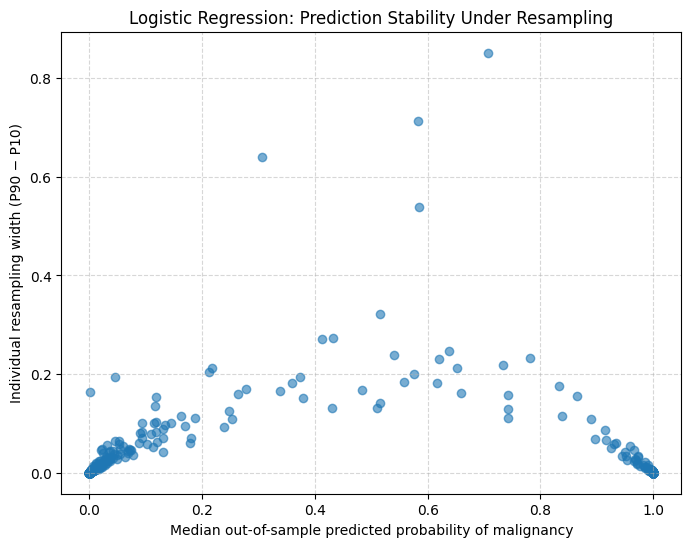


--- 1. OPTIMIZER ITERATIONS SUMMARY ---
count    250.000000
mean      18.360000
std        1.546599
min       14.000000
25%       17.000000
50%       18.000000
75%       20.000000
max       22.000000
Name: n_iter, dtype: float64

--- 2. BRIER SCORE SUMMARY ---
count    50.000000
mean      0.020547
std       0.001677
min       0.017014
25%       0.019437
50%       0.020540
75%       0.021681
max       0.024350
Name: brier, dtype: float64

--- 3. REPETITION-LEVEL AUC SUMMARY ---
count    50.000000
mean      0.994556
std       0.001299
min       0.990156
25%       0.994136
50%       0.994715
75%       0.995375
max       0.996564
Name: auc, dtype: float64

--- 4. INDIVIDUAL RESAMPLING WIDTH (W_i) SUMMARY ---
count    569.000000
mean       0.025813
std        0.074385
min        0.000000
10%        0.000001
25%        0.000073
50%        0.001004
75%        0.012490
90%        0.072620
95%        0.157334
99%        0.271392
max        0.851826
Name: resampling_width, dtype: float64


In [31]:
import matplotlib.pyplot as plt

# 1. Scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(
    lr_individual["median_probability"],
    lr_individual["resampling_width"],
    alpha=0.6
)
plt.xlabel("Median out-of-sample predicted probability of malignancy")
plt.ylabel("Individual resampling width (P90 − P10)")
plt.title("Logistic Regression: Prediction Stability Under Resampling")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# 2. Impresión de los 4 outputs solicitados para análisis
print("\n--- 1. OPTIMIZER ITERATIONS SUMMARY ---")
print(lr_fit_diagnostics["n_iter"].describe())

print("\n--- 2. BRIER SCORE SUMMARY ---")
print(lr_brier["brier"].describe())

print("\n--- 3. REPETITION-LEVEL AUC SUMMARY ---")
print(lr_auc["auc"].describe())

print("\n--- 4. INDIVIDUAL RESAMPLING WIDTH (W_i) SUMMARY ---")
print(lr_individual["resampling_width"].describe(
    percentiles=[.10, .25, .50, .75, .90, .95, .99]
))

## Stage 4F.1: Inspection of Top Instability Cases

To better understand the right tail of the $W_i$ distribution, we inspect the 10 most sensitive observations and examine the full empirical distribution of $OOS$ predicted probabilities across the 50 repetitions for the 3 most extreme cases.

This allows us to distinguish between a **gradual dispersion** in predictions versus a **bimodal/discontinuous jump** caused by specific training perturbations.

In [32]:
# 1. Tabla con las 10 observaciones con mayor W_i
top10_lr = (
    lr_individual
    .sort_values("resampling_width", ascending=False)
    .head(10)
    [[
        "observation_id",
        "y_true",
        "median_probability",
        "p10",
        "p90",
        "resampling_width",
        "prediction_variance",
    ]]
)

print("--- TOP 10 MOST SENSITIVE OBSERVATIONS (LR) ---")
print(top10_lr.to_string(index=False))

# 2. Inspección de los 50 valores individuales de los Top 3 casos
top3_ids = lr_individual.nlargest(3, "resampling_width")["observation_id"].tolist()

print("\n--- FULL 50 OOS PREDICTED PROBABILITIES FOR TOP 3 CASES ---")
for obs_id in top3_ids:
    values = (
        lr_predictions
        .loc[lr_predictions["observation_id"] == obs_id, "predicted_probability"]
        .sort_values()
        .to_numpy()
    )
    print(f"\nObservation ID: {obs_id}")
    print(np.round(values, 4))

--- TOP 10 MOST SENSITIVE OBSERVATIONS (LR) ---
observation_id  y_true  median_probability      p10      p90  resampling_width  prediction_variance
      WDBC_038       1            0.706837 0.042433 0.894260          0.851826             0.104935
      WDBC_068       0            0.582392 0.176582 0.889993          0.713412             0.069829
      WDBC_190       1            0.305278 0.132610 0.772342          0.639732             0.052532
      WDBC_146       1            0.584808 0.272325 0.810990          0.538665             0.038735
      WDBC_238       0            0.516281 0.370478 0.692961          0.322483             0.014637
      WDBC_157       0            0.432844 0.304906 0.577976          0.273071             0.011815
      WDBC_455       0            0.413379 0.325616 0.596218          0.270602             0.012830
      WDBC_541       0            0.637519 0.519081 0.765913          0.246832             0.009351
      WDBC_013       1            0.539891 0.401128 

## Stage 4H: Monte-Carlo Precision Diagnostic for Primary Stability Summaries

Before concluding Stage 4, we evaluate whether $R = 50$ repetitions are numerically sufficient to produce stable estimates of our primary cohort-level stability summaries:
- $\text{Median}(W_i)$
- $P_{90}(W_i)$

We draw $B = 2,000$ non-parametric Monte-Carlo resamples of the **repetitions** (resampling complete columns of the $569 \times 50$ probability matrix). 

> **Note:** This diagnostic quantifies the *approximation error* introduced by using 50 realizations instead of an infinite number of repetitions; it is **not** a population confidence interval.

In [33]:
# 1. Matriz de probabilidades (569 observaciones x 50 repeticiones)
lr_probability_matrix = (
    lr_predictions
    .pivot(
        index="observation_id",
        columns="repeat",
        values="predicted_probability"
    )
)

assert lr_probability_matrix.shape == (569, 50)

# 2. Resampling Monte-Carlo
MC_BOOTSTRAPS = 2000
MC_SEED = 20260924

rng = np.random.default_rng(MC_SEED)
mc_results = []
P = lr_probability_matrix.to_numpy()

for b in range(MC_BOOTSTRAPS):
    sampled_repeats = rng.integers(0, P.shape[1], size=P.shape[1])
    Pb = P[:, sampled_repeats]

    p10_b = np.quantile(Pb, 0.10, axis=1, method="linear")
    p90_b = np.quantile(Pb, 0.90, axis=1, method="linear")
    widths_b = p90_b - p10_b

    mc_results.append({
        "median_width": np.median(widths_b),
        "p90_width": np.quantile(widths_b, 0.90, method="linear"),
    })

mc_results = pd.DataFrame(mc_results)

# 3. Resumen de Precisión de Monte-Carlo
mc_summary = pd.DataFrame({
    "estimate": [
        lr_individual["resampling_width"].median(),
        lr_individual["resampling_width"].quantile(0.90),
    ],
    "MC_SE": [
        mc_results["median_width"].std(ddof=1),
        mc_results["p90_width"].std(ddof=1),
    ],
    "MC_P2.5": [
        mc_results["median_width"].quantile(0.025),
        mc_results["p90_width"].quantile(0.025),
    ],
    "MC_P97.5": [
        mc_results["median_width"].quantile(0.975),
        mc_results["p90_width"].quantile(0.975),
    ],
}, index=["median_W", "P90_W"])

print("--- MONTE-CARLO APPROXIMATION DIAGNOSTIC (R=50) ---")
print(mc_summary)

--- MONTE-CARLO APPROXIMATION DIAGNOSTIC (R=50) ---
          estimate     MC_SE   MC_P2.5  MC_P97.5
median_W  0.001004  0.000036  0.000931  0.001068
P90_W     0.072620  0.004159  0.067244  0.083122


## Monte Carlo precision of the primary stability summaries

The numerical precision of the individual-stability summaries was evaluated
by resampling complete redevelopment repetitions.

With 50 repetitions:

- median individual resampling width:
  `0.001004`, Monte Carlo SE `0.000036`;

- 90th percentile individual resampling width:
  `0.072620`, Monte Carlo SE `0.004159`.

The corresponding Monte Carlo diagnostic ranges were approximately
`0.000931–0.001068` for the median and `0.067244–0.083122` for the
90th percentile.

These ranges quantify numerical sensitivity to the finite number of
redevelopment repetitions. They are not confidence intervals for a patient
population or for an individual's true probability.

The precision was considered sufficient for the descriptive cohort-level
objectives of Project 1, so the prespecified initial 50 repetitions were
retained.

In [34]:
top10_lr = (
    lr_individual
    .sort_values(
        "resampling_width",
        ascending=False
    )
    .head(10)
    [
        [
            "observation_id",
            "y_true",
            "median_probability",
            "p10",
            "p90",
            "resampling_width",
            "prediction_variance",
        ]
    ]
)

top10_lr

,observation_id,y_true,median_probability,p10,p90,resampling_width,prediction_variance
38,WDBC_038,1,0.706837,0.042433,0.894260,0.851826,0.104935
68,WDBC_068,0,0.582392,0.176582,0.889993,0.713412,0.069829
190,WDBC_190,1,0.305278,0.132610,0.772342,0.639732,0.052532
146,WDBC_146,1,0.584808,0.272325,0.810990,0.538665,0.038735
238,WDBC_238,0,0.516281,0.370478,0.692961,0.322483,0.014637
157,WDBC_157,0,0.432844,0.304906,0.577976,0.273071,0.011815
455,WDBC_455,0,0.413379,0.325616,0.596218,0.270602,0.012830
541,WDBC_541,0,0.637519,0.519081,0.765913,0.246832,0.009351
13,WDBC_013,1,0.539891,0.401128,0.640232,0.239104,0.009659
489,WDBC_489,1,0.780917,0.647748,0.879911,0.232163,0.010298


In [35]:
top3_ids = (
    lr_individual
    .nlargest(3, "resampling_width")
    ["observation_id"]
    .tolist()
)

for obs_id in top3_ids:

    values = (
        lr_predictions
        .loc[
            lr_predictions["observation_id"] == obs_id,
            "predicted_probability"
        ]
        .sort_values()
        .to_numpy()
    )

    print(f"\n{obs_id}")
    print(np.round(values, 4))


WDBC_038
[0.007  0.015  0.0208 0.0238 0.0417 0.0425 0.0467 0.0475 0.0478 0.0708
 0.0841 0.0964 0.519  0.5274 0.5891 0.5932 0.6183 0.6242 0.6542 0.6816
 0.6941 0.6951 0.698  0.7007 0.7064 0.7073 0.719  0.7298 0.7573 0.7616
 0.7641 0.7891 0.7894 0.8027 0.8053 0.8112 0.8141 0.8164 0.8188 0.8189
 0.8467 0.8649 0.8789 0.8889 0.8942 0.8951 0.8984 0.8988 0.9334 0.9348]

WDBC_068
[0.0716 0.0757 0.1061 0.1515 0.169  0.1774 0.1781 0.1948 0.2147 0.2515
 0.2632 0.2648 0.2764 0.3336 0.363  0.3675 0.373  0.4293 0.4639 0.497
 0.505  0.5573 0.5704 0.5724 0.5811 0.5836 0.5873 0.6012 0.602  0.6206
 0.6344 0.6499 0.6719 0.7011 0.7122 0.7434 0.7486 0.7523 0.7635 0.7825
 0.8094 0.8374 0.841  0.8718 0.8895 0.8942 0.8948 0.9042 0.9499 0.957 ]

WDBC_190
[0.0894 0.1066 0.1133 0.125  0.1291 0.133  0.1407 0.142  0.1428 0.1445
 0.1462 0.1524 0.1565 0.163  0.1874 0.2197 0.2386 0.2391 0.2693 0.2735
 0.2739 0.277  0.2797 0.2844 0.3025 0.308  0.3332 0.3646 0.3744 0.3853
 0.4123 0.4422 0.4438 0.4606 0.4767 0.4853 0.4

In [36]:
lr_individual["central80_crosses_05"] = (
    (lr_individual["p10"] < 0.5)
    &
    (lr_individual["p90"] > 0.5)
)

print(
    lr_individual["central80_crosses_05"]
    .value_counts()
)

print(
    "\nProportion:",
    lr_individual["central80_crosses_05"].mean()
)

central80_crosses_05
False    555
True      14
Name: count, dtype: int64

Proportion: 0.02460456942003515


### Threshold-crossing sensitivity

For 14 of 569 observations (2.46%), the central 80% resampling interval
(P10–P90) crossed the reference threshold of 0.5.

This quantity is descriptive only. The threshold of 0.5 has no claimed
clinical decision meaning in this study.

The result illustrates why probability stability is the primary object of
interest: substantial changes in predicted probability can occur without
necessarily producing a change in binary classification.

## Stage 4 checkpoint

At this checkpoint, the following components have been completed before
analysis of the Random Forest procedure:

- dataset provenance and structural audit;
- frozen analysis data contract;
- frozen repeated stratified 5-fold resampling design;
- prevalence-only control;
- prespecified L2 logistic-regression procedure;
- 28,450 genuine out-of-sample logistic-regression predictions;
- aggregate ROC-AUC and Brier-score stability analysis;
- individual prediction resampling-width analysis;
- Monte Carlo precision assessment for the primary stability summaries;
- descriptive inspection of highly resampling-sensitive observations.

No Random Forest results have been examined at this stage.